In [1]:
%%capture
import wget
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib import pyplot
import numpy as np

from restricted_boltzmann import RestrictedBoltzmann
from restricted_boltzmann.tools import RBMReportGenerator
from zipfile import ZipFile

## Theoretical Background: Genetic Algorithm (GA) Training

A **Restricted Boltzmann Machine (RBM)** is an energy-based generative model with a visible layer $\mathbf{v} \in \{0,1\}^{n_v}$ and a hidden layer $\mathbf{h} \in \{0,1\}^{n_h}$, governed by the energy function:

$$
E(\mathbf{v}, \mathbf{h}) = -\mathbf{v}^\top \mathbf{W} \mathbf{h} - \mathbf{b}^\top \mathbf{v} - \mathbf{c}^\top \mathbf{h}
$$

where $\mathbf{W}$ is the weight matrix, $\mathbf{b}$ are the visible biases, and $\mathbf{c}$ are the hidden biases. The conditional distributions are sigmoid activations:

$$
P(h_j = 1 | \mathbf{v}) = \sigma\left(\sum_i W_{ij} v_i + c_j\right), \quad P(v_i = 1 | \mathbf{h}) = \sigma\left(\sum_j W_{ij} h_j + b_i\right)
$$

Instead of gradient-based optimization (e.g., contrastive divergence), a **Genetic Algorithm (GA)** treats the RBM parameters as a population of candidate solutions and evolves them through biologically-inspired operators. Each individual encodes the full parameter set $\theta = (\mathbf{W}, \mathbf{b}, \mathbf{c})$ as its genome.

### Algorithm Overview

1. **Initialization**: Generate a population of $N$ random individuals, each with weights $W_{ij} \sim \mathcal{N}(0, 0.2^2)$ and small positive biases.

2. **Fitness evaluation**: For each individual, compute the reconstruction error on a validation subset:

$$
\text{Error}(\theta) = \frac{1}{m} \sum_{i=1}^{m} \| \mathbf{v}_i - \hat{\mathbf{v}}_i \|^2, \quad \hat{\mathbf{v}}_i = \sigma\left(\sigma(\mathbf{v}_i \mathbf{W} + \mathbf{c}) \mathbf{W}^\top + \mathbf{b}\right)
$$

The **fitness** is defined as $f(\theta) = \frac{1}{1 + \text{Error}(\theta)}$, so higher fitness corresponds to lower reconstruction error.

3. **Selection (Tournament)**: Randomly select $k$ individuals and keep the fittest as a parent. This provides selective pressure while maintaining diversity.

4. **Crossover (BLX-$\alpha$)**: With probability $p_c$, blend two parents to produce an offspring. For each gene $g$ with parent values $a$ and $b$:

$$
g \sim U\left(\min(a,b) - \alpha|a-b|, \; \max(a,b) + \alpha|a-b|\right), \quad \alpha = 0.5
$$

5. **Mutation (Gaussian)**: With probability $p_m$ per gene, add Gaussian noise $\mathcal{N}(0, 0.1^2)$ to explore the search space and prevent premature convergence.

6. **Elitism**: Preserve the $E$ fittest individuals unchanged into the next generation to guarantee monotonic improvement of the best solution.

7. **Iterate**: Repeat steps 2-6 for $G$ generations. The fittest individual in the final population is assigned to the model.

This evolutionary approach is gradient-free, making it robust to non-differentiable or noisy fitness landscapes, and it naturally explores a diverse set of parameter configurations.

In [2]:
# url = "http://files.grouplens.org/datasets/movielens/ml-1m.zip"
# filename = wget.download(url)

with ZipFile("ml-1m.zip", "r") as zObject:
    zObject.extractall()

In [3]:
movies_df = pd.read_csv(
    "ml-1m/movies.dat", sep="::", header=None, engine="python", encoding="latin_1"
)
movies_df.head()

,0,1,2
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
# loading in the ratings dataset
ratings_df = pd.read_csv("ml-1m/ratings.dat", sep="::", header=None, engine="python")
ratings_df.head()

,0,1,2,3
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [5]:
movies_df.columns = ["MovieID", "Title", "Genres"]
movies_df.head()

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
ratings_df.columns = ["UserID", "MovieID", "Rating", "Timestamp"]
ratings_df.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [7]:
user_rating_df = ratings_df.pivot(index="UserID", columns="MovieID", values="Rating")
user_rating_df.head()  # 5 rows x 3706 columns
norm_user_rating_df = user_rating_df.fillna(0) / 5.0
trX = norm_user_rating_df.values
norm_user_rating_df.head()

MovieID,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
UserID,,,,,,,,,,,,,,,,,,,,,
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Training with a Genetic Algorithm

Instead of contrastive divergence, we evolve a population of candidate weight matrices using selection, crossover and mutation. The fitness is the inverse of the reconstruction error on a validation subset.

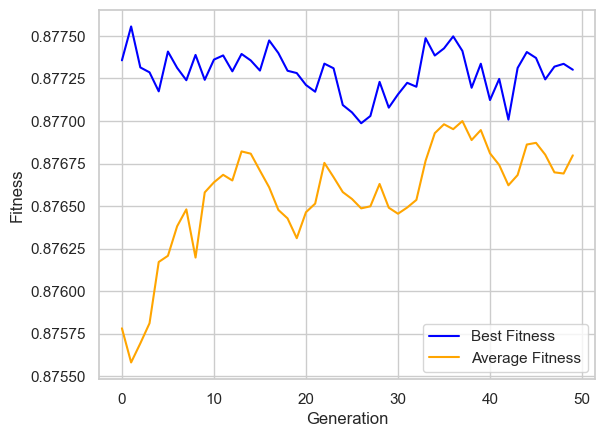

Best fitness: 0.8775


In [8]:
hidden_units = 10
visible_units = len(user_rating_df.columns)

model = RestrictedBoltzmann()
model.train_genetic(
    trX,
    hidden_units,
    visible_units,
    population_size=20,
    generations=50,
    mutation_rate=0.1,
    crossover_rate=0.7,
    elite_size=2,
    tournament_size=3,
    plot=True,
    verbose=True,
)

In [9]:
mock_user_id = 215
input_user = trX[mock_user_id - 1].reshape(1, -1)
input_user[0:5]

array([[0.8, 0. , 0. , ..., 0. , 0. , 0. ]])

In [10]:
output_user = model.predict_proba(input_user)
output_user[0:5]

array([[0.48736143, 0.6133995 , 0.5214474 , ..., 0.5388804 , 0.40210474,
        0.65940803]], dtype=float32)

In [11]:
threshold = 0.70
movies_id = list(np.where(output_user[0, :] > threshold)[0])
movies_recomendation = np.where(output_user[0, :] >= np.mean(output_user[0, movies_id]))[0]
print(movies_recomendation)

[ 990 2078 2256 3238 3557]


In [12]:
model_checkpoint = "model/ml-rbm-genetic"
model.save_model(model_checkpoint)

In [13]:
model = RestrictedBoltzmann()
model.load_model(model_checkpoint, hidden_units=hidden_units, visible_units=visible_units)

In [14]:
output_user = model.predict_proba(input_user)
output_user[0:5]

array([[0.48736143, 0.6133995 , 0.5214474 , ..., 0.5388804 , 0.40210474,
        0.65940803]], dtype=float32)

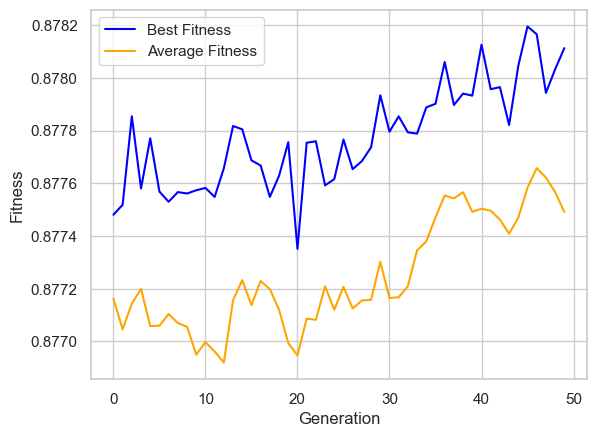

Best fitness: 0.8780


In [15]:
# Re-training with the genetic algorithm
model.train_genetic(
    trX,
    hidden_units,
    visible_units,
    population_size=20,
    generations=50,
    mutation_rate=0.1,
    crossover_rate=0.7,
    elite_size=2,
    tournament_size=3,
    plot=True,
    verbose=True,
    warm_start=True,
)

In [16]:
# View predictions after re-training
output_user = model.predict_proba(input_user)
output_user[0:5]

array([[0.51182914, 0.59762245, 0.2902886 , ..., 0.45143035, 0.46365312,
        0.6164526 ]], dtype=float32)

In [17]:
# Display new recommendations
movies_recomendation = np.where(output_user[0, :] >= np.mean(output_user[0, movies_id]))[0]
print(movies_recomendation)

[  21  246  280  287  404  689  696  774  836 1094 1637 1663 1692 1857
 1965 2078 2086 2120 2350 2599 2636 2719 2981 3023 3059 3238 3501 3557]


In [18]:
model.summary()

                  Model Summary                   
Layer                Type            Shape                     Parameters               
---------------------------------------------------------------------------
Visible Layer        Bias            (3706, )                  3706                     
(Vis -> Hidden)      Weight          (3706,  10)               37060                    
Hidden Layer         Bias            (10, )                    10                       
---------------------------------------------------------------------------
Total Layers                             2                        
Total Parameters                         40776                    
Model Size (Approx)                      0.16 MB


In [19]:
model.summarize_statistics()

                Summary Statistics                
Weights:
---------------------------------------------------------------------------
Mean:    -0.0130, Std:     0.3336, Sparsity:     0.5168
Visible Biases:
---------------------------------------------------------------------------
Mean:    -0.0227, Std:     0.2650
Hidden Biases:
---------------------------------------------------------------------------
Mean:    -0.2887, Std:     0.2974


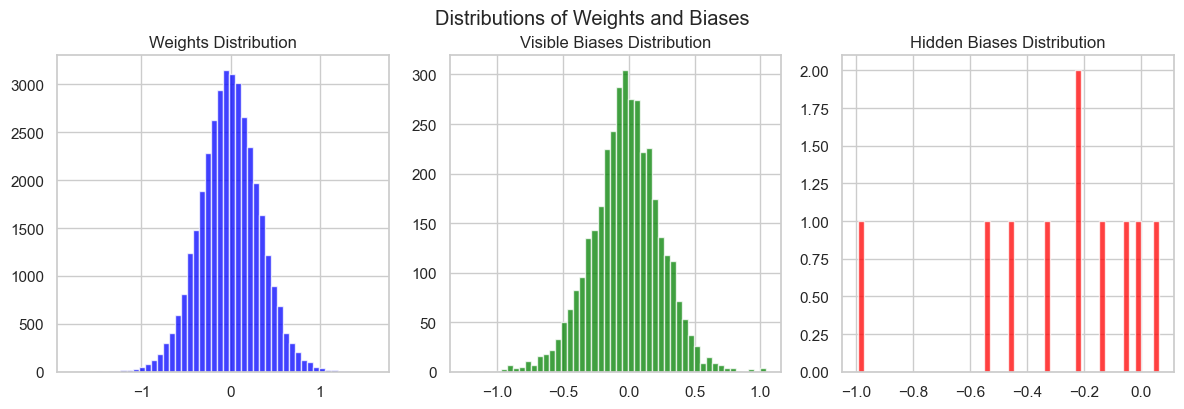

In [20]:
model.plot_distributions()

In [21]:
activations = model.get_hidden_activations(trX)
activations[0, 0:5]

array([0.13127603, 0.02499247, 0.09028844, 0.03075664, 0.10823247],
      dtype=float32)

In [22]:
reporter = RBMReportGenerator()
reporter.generate(activations, trX[:, :3600])

🚀 Insight Report generated at: reports\rbm.html
